In [4]:
!pip install pandas matplotlib seaborn numpy


Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks with 0 as tenure is 0 and no total charges are recorded 

In [9]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",0)
df['TotalCharges'] = df['TotalCharges'].astype("float")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [18]:
df['customerID'].duplicated().sum()

np.int64(0)

In [20]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

#converted 0 and 1 value of senior citizen to yes/no to make it easier to understand

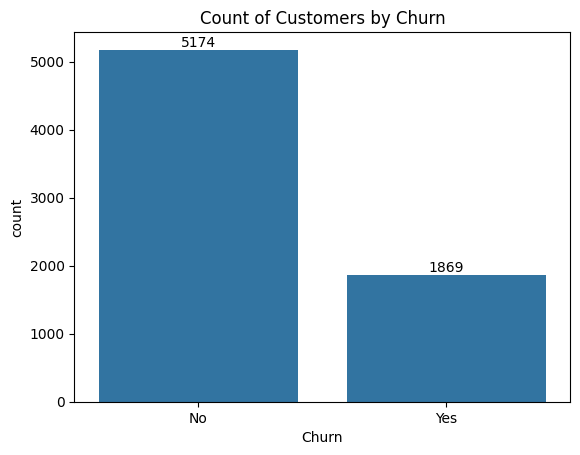

In [39]:
ax = sns.countplot(data = df, x = 'Churn')
plt.title("Count of Customers by Churn")
ax.bar_label(ax.containers[0])
plt.show()

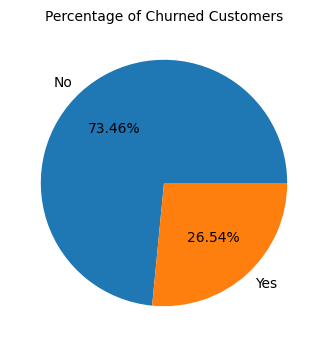

In [40]:
plt.figure(figsize = (4,4))
gb = df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'], labels = gb.index, autopct = '%1.2f%%')
plt.title("Percentage of Churned Customers" , fontsize = 10)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out 
#not let's explore the reason behind it

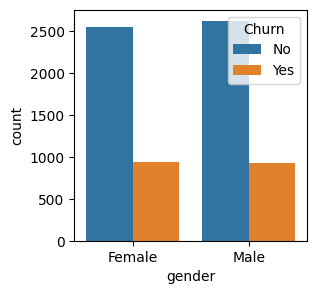

In [44]:
plt.figure(figsize = (3,3))
sns.countplot(x = 'gender', data= df, hue = 'Churn')
plt.title('Churn by gender')
plt.show()

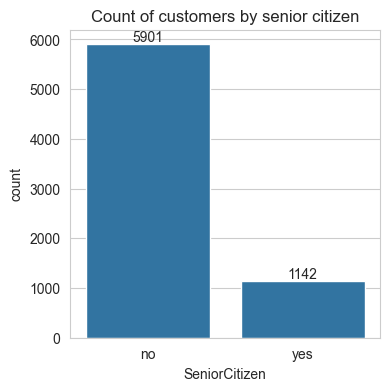

In [67]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = 'SeniorCitizen', data= df)
ax.bar_label(ax.containers[0])
plt.title('Count of customers by senior citizen')
plt.show()

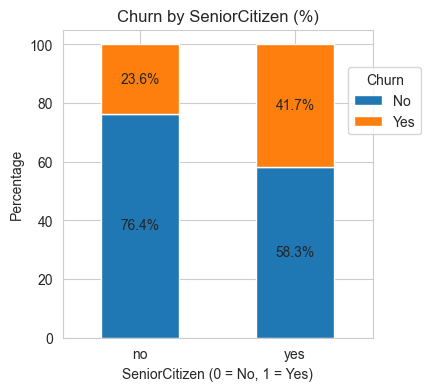

In [62]:

# STEP 1: Create percentage table
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# STEP 2: Plot stacked bar chart
ax = ct.plot(kind='bar', stacked=True, figsize=(4,4))

# STEP 3: Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

# STEP 4: Formatting
plt.title('Churn by SeniorCitizen (%)')
plt.xlabel('SeniorCitizen (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))
plt.xticks(rotation=0)

plt.show()

#comparitive a greater percentage of people in senior citizen category have churned.

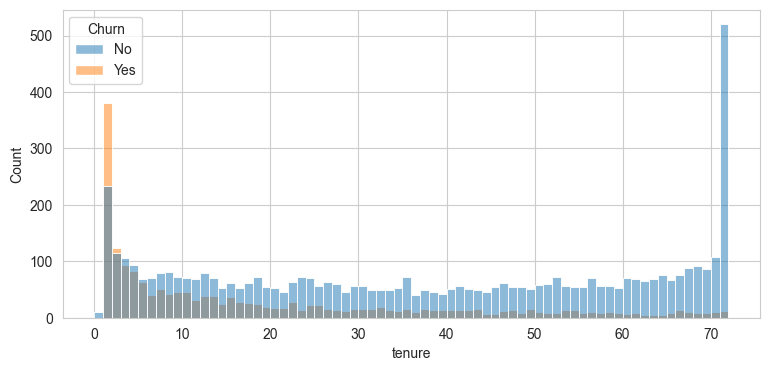

In [60]:
plt.figure(figsize = (9,4))
sns.histplot(x = 'tenure', data = df, bins=72, hue='Churn')
plt.show()

#people who have used services for  long time have stayed and people who have used our services 1 or 2 months have churned

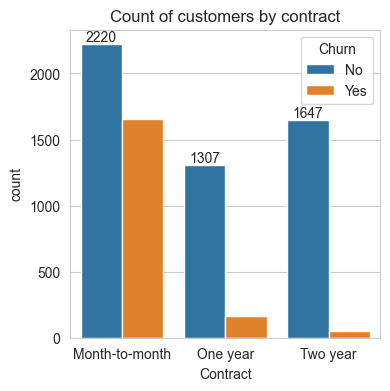

In [66]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = 'Contract', data= df, hue='Churn')
ax.bar_label(ax.containers[0])
plt.title('Count of customers by contract')
plt.show()

#people who have month to month contract are likely to churn then from those who have one or two years of contract 

In [68]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

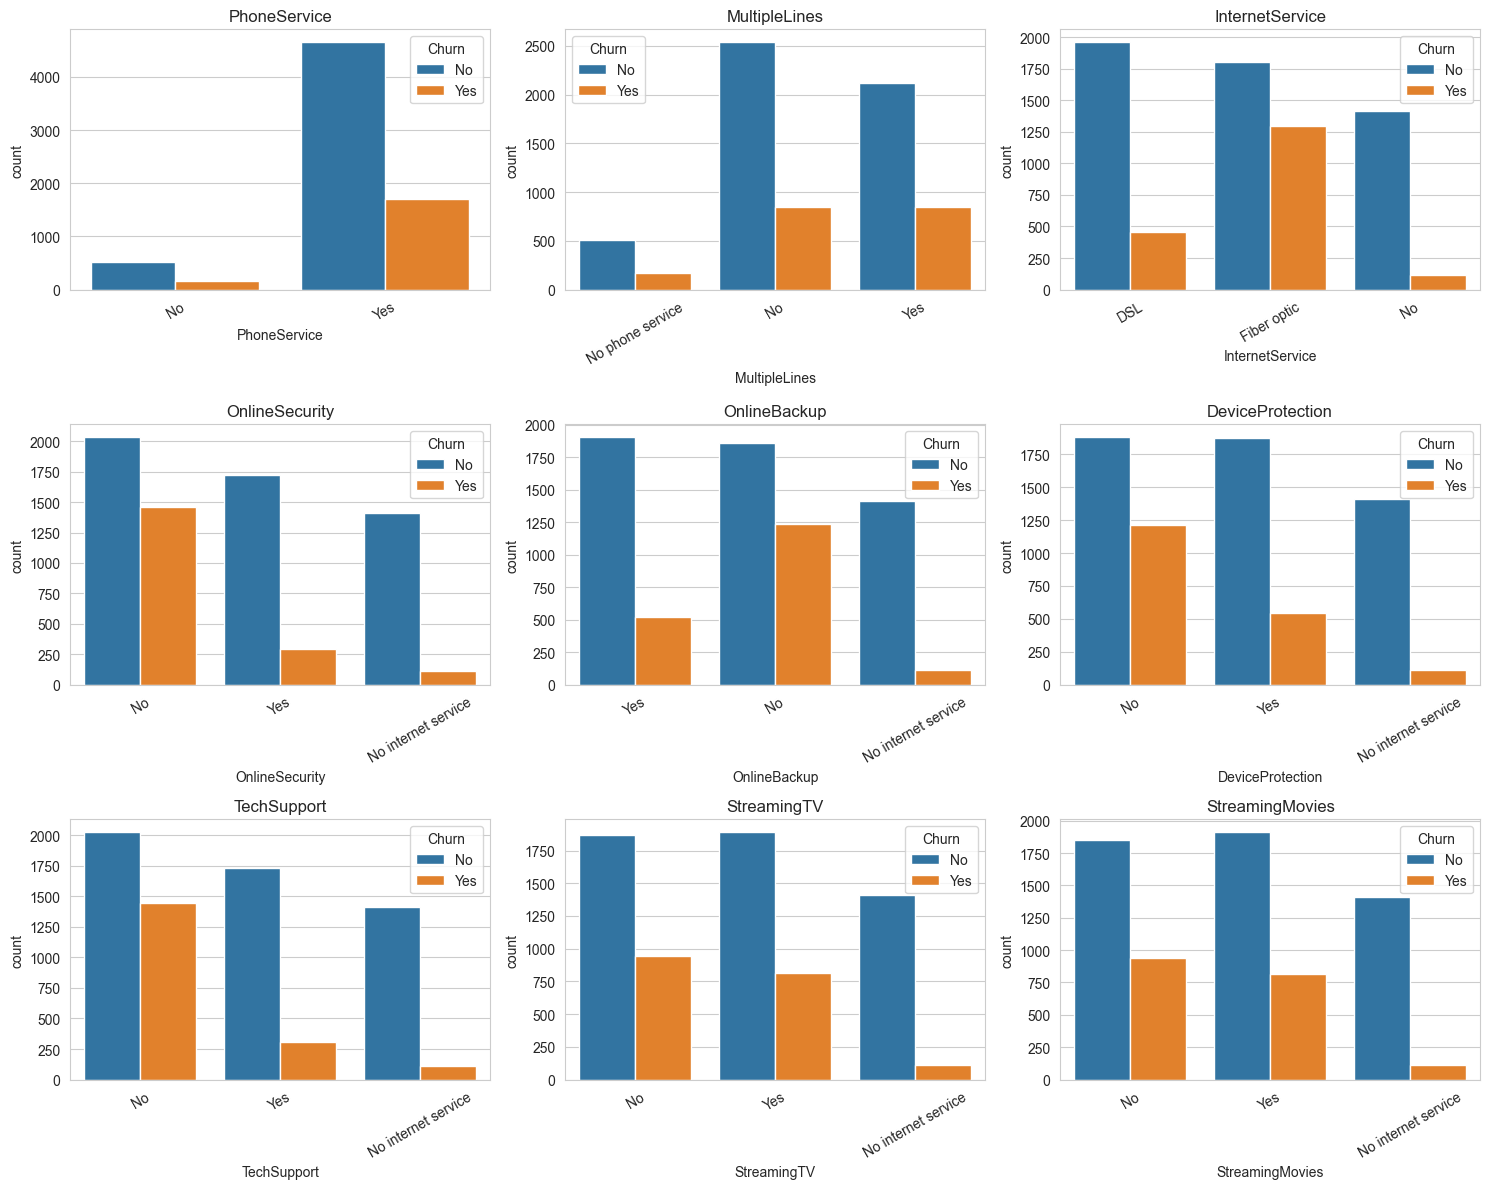

In [71]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# layout (3x3 grid since 9 columns)
rows = 3
cols_grid = 3

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(rows, cols_grid, i)
    sns.countplot(x=col, data=df, hue='Churn')
    plt.title(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

#Customers without value-added services (like OnlineSecurity, TechSupport, DeviceProtection) show significantly higher churn compared to those who have these services.
Fiber optic internet users tend to churn more than DSL users, indicating possible dissatisfaction or pricing issues.
Streaming services (TV/Movies) and phone-related services show relatively balanced churn, suggesting they are not strong drivers of customer loss.
Overall, lack of support/security services is the strongest indicator of churn in this dataset.

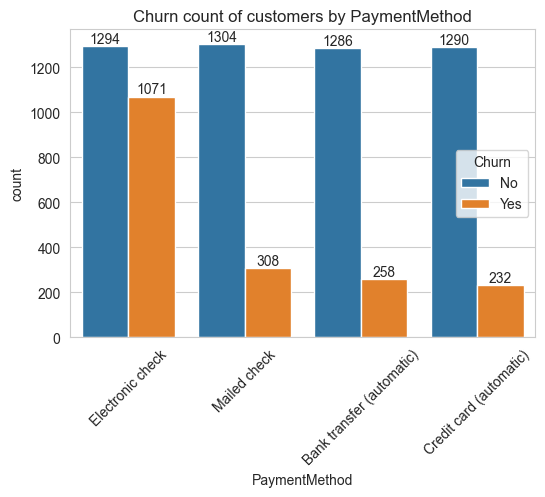

In [77]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = 'PaymentMethod', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churn count of customers by PaymentMethod')
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he is using electronic check as a payment mathod